In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import import_ipynb
from simca import SIMCAModel, SIMCAClassModel
%matplotlib inline

data/Replicate_011/Replicate_011_20251119: 10 FLUO files
data/Replicate_012/Replicate_012_20251119: 10 FLUO files
data/Replicate_021/Replicate_021_20251119: 10 FLUO files
data/Replicate_022/Replicate_022_20251119: 10 FLUO files

Ukupan broj XVOO_NONE FLUO merenja: 40
xvoo_none_raw shape: (40, 288)


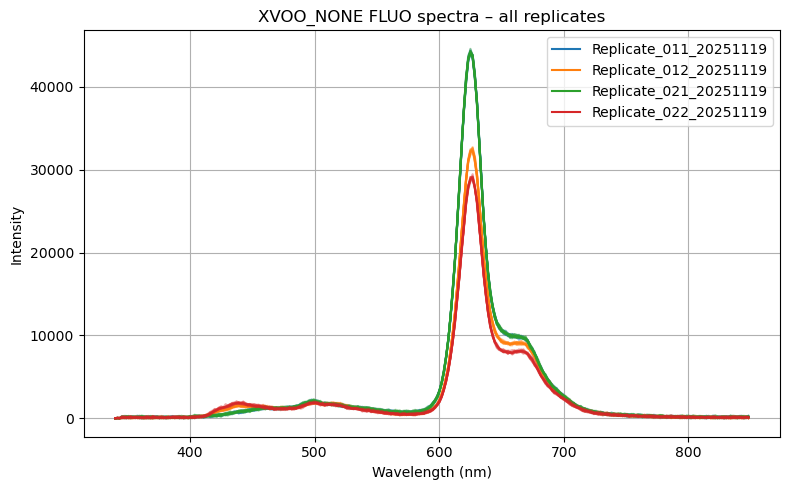

In [2]:
replicate_folders = [
    r"data/Replicate_011/Replicate_011_20251119",
    r"data/Replicate_012/Replicate_012_20251119",
    r"data/Replicate_021/Replicate_021_20251119",
    r"data/Replicate_022/Replicate_022_20251119",
]

xvoo_none_raw = []
wavelengths = None
file_counter = 0

for base_folder in replicate_folders:
    xvoo_none_fluo_path = os.path.join(base_folder, "xvoo_none", "FLUO")

    if not os.path.exists(xvoo_none_fluo_path):
        print(f"Warning: {xvoo_none_fluo_path} does not exist, skipping...")
        continue

    files = sorted(glob.glob(os.path.join(xvoo_none_fluo_path, "*.csv")))
    print(f"{base_folder}: {len(files)} FLUO files")

    for fpath in files:
        df = pd.read_csv(fpath)

        if wavelengths is None:
            wavelengths = df["x"].values
        else:
            assert np.allclose(wavelengths, df["x"].values), \
                "Wavelengths do not match between replicates!"

        xvoo_none_raw.append(df["y"].values)
        file_counter += 1

xvoo_none_raw = np.array(xvoo_none_raw)

print(f"\nUkupan broj XVOO_NONE FLUO merenja: {file_counter}")
print("xvoo_none_raw shape:", xvoo_none_raw.shape)

plt.figure(figsize=(8, 5))

rep_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

for i, base_folder in enumerate(replicate_folders):
    rep_name = os.path.basename(base_folder)
    
    start_idx = sum(len(glob.glob(os.path.join(f, "xvoo_none", "FLUO", "*.csv"))) 
                    for f in replicate_folders[:i])
    end_idx = start_idx + len(glob.glob(os.path.join(base_folder, "xvoo_none", "FLUO", "*.csv")))
    
    spectra = xvoo_none_raw[start_idx:end_idx]
    
    for spec in spectra:
        plt.plot(wavelengths, spec, color=rep_colors[i], alpha=0.4)
    
    plt.plot([], [], color=rep_colors[i], alpha=1, label=rep_name)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("XVOO_NONE FLUO spectra – all replicates")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Replicate_011_20251119 WR shape: (288, 2)
Replicate_012_20251119 WR shape: (288, 2)
Replicate_021_20251119 WR shape: (288, 2)
Replicate_022_20251119 WR shape: (288, 2)


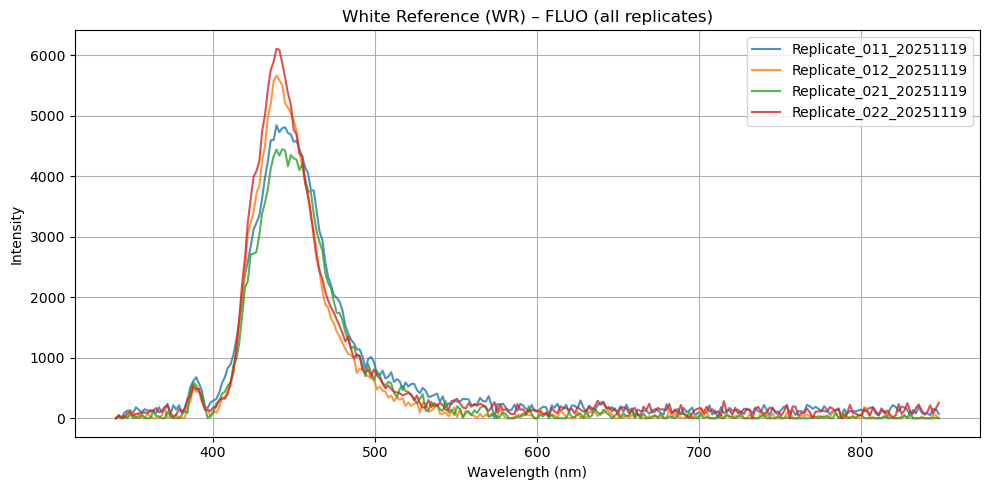

In [3]:
wr_fluo_dict = {}

for base_folder in replicate_folders:
    rep_name = os.path.basename(base_folder)  # ime replicata
    wr_path = os.path.join(base_folder, "wr", "FLUO_WR.csv")

    if not os.path.exists(wr_path):
        print(f"Warning: WR does not exist for {rep_name}")
        continue

    wr_df = pd.read_csv(wr_path)

    wl_wr = wr_df["x"].values
    I_wr = wr_df["y"].values

    wr_fluo_dict[rep_name] = I_wr

    print(f"{rep_name} WR shape:", wr_df.shape)

    if "wavelengths" in globals():
        assert np.allclose(wavelengths, wl_wr), f"{rep_name}: WR and spectra wavelengths do not match!"

plt.figure(figsize=(10, 5))

rep_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

for i, base_folder in enumerate(replicate_folders):
    rep_name = os.path.basename(base_folder)
    I_wr = wr_fluo_dict[rep_name]
    wl_wr = wavelengths

    plt.plot(wl_wr, I_wr, color=rep_colors[i], alpha=0.8, label=rep_name)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("White Reference (WR) – FLUO (all replicates)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

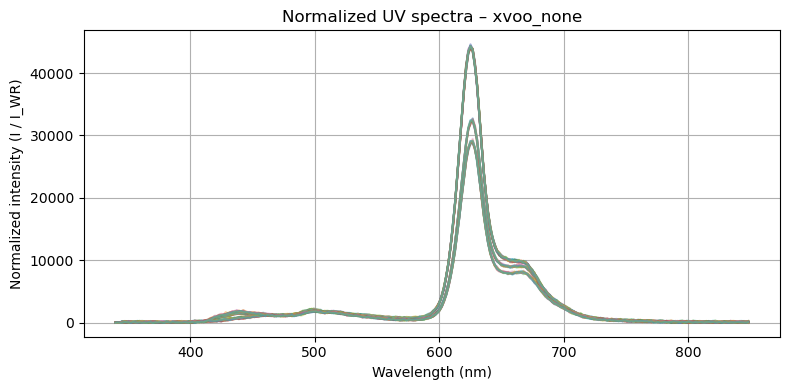

In [4]:
xvoo_none_norm = xvoo_none_raw / 1.0

plt.figure(figsize=(8, 4))

for i in range(len(xvoo_none_norm)):
    plt.plot(wavelengths, xvoo_none_norm[i], alpha=0.4)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized intensity (I / I_WR)")
plt.title("Normalized UV spectra – xvoo_none")
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
xvoo_none_norm.shape

(40, 288)

Optimal number of PCA components per class: {'XVOO_NONE': 1}
SIMCA thresholds:
ODcrit: 8324615.316471765
SDcrit: 4.1935605219491325
Inside class (True = sample accepted): [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True False  True  True False  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True]


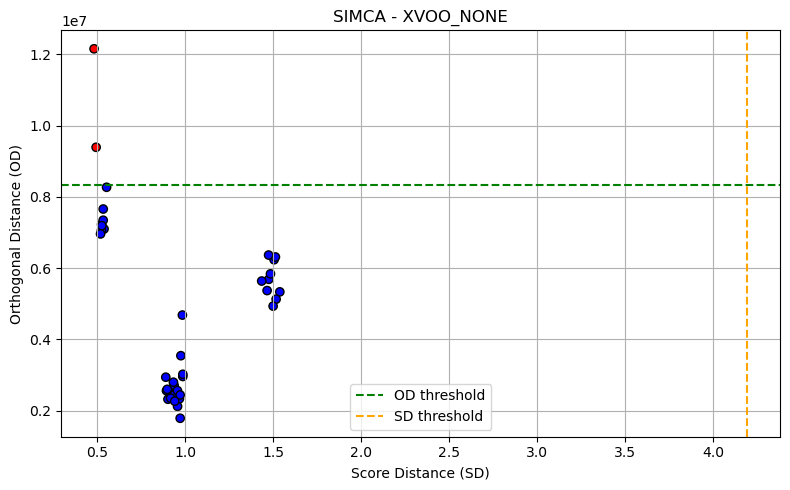

In [6]:
X = xvoo_none_norm
y = np.array(["XVOO_NONE"] * X.shape[0])

simca = SIMCAModel(alpha=0.05, default_n_components=None)

comp_grid = list(range(1, min(10, X.shape[1])+1))
best_components = simca.tune_num_components(
    X, y,
    comp_grid=comp_grid,
    cv=5,
    mode='rigorous',    # 'rigorous', 'compliant'
    rule='sim',         # 'sim', 'alt', 'ci', 'dd'
    od_method='percentile',    # 'percentile', 'jackson', 'box'
    sd_method='f'       # 'f', 'chi2', 'percentile'
)
print("Optimal number of PCA components per class:", best_components)

simca.fit(X, y, n_components=list(best_components.values())[0])

simca.set_thresholds_all(od_method='percentile', sd_method='f')

results = simca.predict(X, rule='sim')
res = results['XVOO_NONE']

print("SIMCA thresholds:")
print("ODcrit:", res.get('ODcrit', None))
print("SDcrit:", res.get('SDcrit', None))
print("Inside class (True = sample accepted):", res['inside'])

plt.figure(figsize=(8,5))
colors = np.where(res['inside'], 'blue', 'red')
plt.scatter(res['SD'], res['OD'], c=colors, edgecolor='k')
plt.axhline(simca.class_models['XVOO_NONE'].thresholds['ODcrit'], color='green', linestyle='--', label='OD threshold')
plt.axvline(simca.class_models['XVOO_NONE'].thresholds['SDcrit'], color='orange', linestyle='--', label='SD threshold')
plt.xlabel("Score Distance (SD)")
plt.ylabel("Orthogonal Distance (OD)")
plt.title("SIMCA - XVOO_NONE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
# plt.figure(figsize=(12,10))

# rules = {'SIMCA':'sim', 'Alt-SIMCA':'alt', 'CI-SIMCA':'ci', 'DD-SIMCA':'dd'}
# for i, (name, rule) in enumerate(rules.items(), 1):
#     res = simca.predict(X, rule=rule)['XVOO_NONE']
    
#     colors = ['blue' if flag else 'red' for flag in res['inside']]
    
#     plt.subplot(2,2,i)
#     plt.scatter(res['SD'], res['OD'], c=colors, edgecolor='k')
#     plt.axhline(simca.class_models['XVOO_NONE'].thresholds['ODcrit'], color='green', linestyle='--', label='OD threshold')
#     plt.axvline(simca.class_models['XVOO_NONE'].thresholds['SDcrit'], color='orange', linestyle='--', label='SD threshold')
#     plt.title(name)
#     plt.xlabel("SD")
#     plt.ylabel("OD")
#     plt.grid(True)

# plt.tight_layout()
# plt.show()

In [8]:
datasets = [
    {
        "base_folder": r"C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_011\Replicate_011_20251205",
        "mixtures": ["xvoo_oo10", "xvoo_oo20", "xvoo_oo30", "xvoo_oo40",
                     "xvoo_oo60", "xvoo_oo70", "xvoo_oo80"]
    },
    {
        "base_folder": r"C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_012\Replicate_012_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100", "xvoo_none",
                     "xvoo_oo50", "xvoo_oo100",
                     "xvoo_sfo50", "xvoo_sfo100"]
    },
        {
        "base_folder": r"C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_021\Replicate_021_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100", "xvoo_none",
                     "xvoo_oo50", "xvoo_oo100",
                     "xvoo_sfo50", "xvoo_sfo100"]
    },
        {
        "base_folder": r"C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_022\Replicate_022_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100", "xvoo_none",
                     "xvoo_oo50", "xvoo_oo100",
                     "xvoo_sfo50", "xvoo_sfo100"]
    }
]

X_list = []
y_list = []

for ds in datasets:
    base_folder = ds["base_folder"]
    mixtures = ds["mixtures"]

    wr_file = os.path.join(base_folder, "wr", "FLUO_WR.csv")
    wr = pd.read_csv(wr_file).iloc[:, 1].values

    print(f"\nLoading data from: {base_folder}")
    print(f"WR shape: {wr.shape}")

    for mix in mixtures:
        uv_folder = os.path.join(base_folder, mix, "FLUO")

        if not os.path.exists(uv_folder):
            print(f"Warning: folder does not exist {uv_folder}, skipping...")
            continue

        files = sorted([f for f in os.listdir(uv_folder) if f.endswith(".csv")])

        for f in files:
            df = pd.read_csv(os.path.join(uv_folder, f))
            spectrum = df.iloc[:, 1].values
            spectrum_norm = spectrum / 1.0

            X_list.append(spectrum_norm)
            y_list.append(mix)
    
X_all_norm = np.array(X_list)
y_all = np.array(y_list)

print("Shape X_all_norm:", X_all_norm.shape)
print("Shape y_all:", y_all.shape)

print("Unique classes:", np.unique(y_all))


Loading data from: C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_011\Replicate_011_20251205
WR shape: (288,)

Loading data from: C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_012\Replicate_012_20251119
WR shape: (288,)

Loading data from: C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_021\Replicate_021_20251119
WR shape: (288,)

Loading data from: C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_022\Replicate_022_20251119
WR shape: (288,)
Shape X_all_norm: (420, 288)
Shape y_all: (420,)
Unique classes: ['xvoo_lso100' 'xvoo_lso50' 'xvoo_none' 'xvoo_oo10' 'xvoo_oo100'
 'xvoo_oo20' 'xvoo_oo30' 'xvoo_oo40' 'xvoo_oo50' 'xvoo_oo60' 'xvoo_oo70'
 'xvoo_oo80' 'xvoo_sfo100' 'xvoo_sfo50']


In [9]:
results_mix = simca.predict(X_all_norm, rule='sim')
res_mix = results_mix['XVOO_NONE']

ODcrit = simca.class_models['XVOO_NONE'].thresholds['ODcrit']
SDcrit = simca.class_models['XVOO_NONE'].thresholds['SDcrit']

print("OD threshold:", ODcrit)
print("SD threshold:", SDcrit)

inside = res_mix['inside']
# for i, accepted in enumerate(inside):
    # print(f"Sample {i} ({y_all[i]}): {'Accepted' if accepted else 'Rejected'}")

OD threshold: 8324615.316471765
SD threshold: 4.1935605219491325


In [10]:
%matplotlib qt

In [11]:
SD = res_mix['SD']
OD = res_mix['OD']

classes = np.unique(y_all)

contrast_colors = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#ffff33",
    "#a65628",
    "#f781bf",
    "#999999",
]

class_colors = {cls: contrast_colors[i % len(contrast_colors)] for i, cls in enumerate(classes)}

plt.figure(figsize=(8,5))

for cls in classes:
    idx = y_all == cls
    plt.scatter(
        SD[idx],
        OD[idx],
        color=class_colors[cls],
        edgecolor='k',
        label=cls,
        s=60
    )

plt.axhline(ODcrit, color='green', linestyle='--', label='OD threshold')
plt.axvline(SDcrit, color='orange', linestyle='--', label='SD threshold')

plt.xlabel("Score Distance (SD)")
plt.ylabel("Orthogonal Distance (OD)")
plt.title("SIMCA – All XVOO data by class")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
y_true = np.array([label == "XVOO_NONE" for label in y_all])

y_pred = res_mix['inside']

TP = np.sum((y_true == True) & (y_pred == True))
FN = np.sum((y_true == True) & (y_pred == False))
FP = np.sum((y_true == False) & (y_pred == True))
TN = np.sum((y_true == False) & (y_pred == False))

conf_matrix = pd.DataFrame(
    [[TP, FN],
     [FP, TN]],
    index=["True XVOO", "True MIX"],
    columns=["Predicted IN", "Predicted OUT"]
)

conf_matrix

,Predicted IN,Predicted OUT
True XVOO,0,0
True MIX,28,392


In [13]:
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else np.nan
specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"Sensitivity (Recall for XVOO): {sensitivity*100:.2f}%")
print(f"Specificity (Rejection of MIX): {specificity*100:.2f}%")
print(f"Accuracy: {accuracy*100:.2f}%")

Sensitivity (Recall for XVOO): nan%
Specificity (Rejection of MIX): 93.33%
Accuracy: 93.33%


In [14]:
results_table = pd.DataFrame({
    "Sample index": np.arange(len(y_all)),
    "True label": y_all,
    "SIMCA accepted": y_pred,
    "Decision": np.where(y_pred, "Accepted", "Rejected"),
    "SD": res_mix['SD'],
    "OD": res_mix['OD']
})

results_table.head(30)

,Sample index,True label,SIMCA accepted,Decision,SD,OD
0,0,xvoo_oo10,False,Rejected,0.004433,9.921513e+07
1,1,xvoo_oo10,False,Rejected,0.002109,9.762887e+07
2,2,xvoo_oo10,False,Rejected,0.002410,9.850222e+07
3,3,xvoo_oo10,False,Rejected,0.007726,1.072867e+08
4,4,xvoo_oo10,False,Rejected,0.007198,1.133252e+08
5,5,xvoo_oo10,False,Rejected,0.002698,9.808773e+07
6,6,xvoo_oo10,False,Rejected,0.003658,1.003168e+08
7,7,xvoo_oo10,False,Rejected,0.008824,1.084846e+08
8,8,xvoo_oo10,False,Rejected,0.007600,1.094233e+08
9,9,xvoo_oo10,False,Rejected,0.004718,9.789158e+07
